# Teen Mental Health — Preprocesamiento

Este notebook transforma el dataset en crudo en un formato listo para modelado.  
Cada decisión se fundamenta en los hallazgos del EDA (`01_eda.ipynb`) y en métricas estadísticas calculadas aquí.

**Resumen de hallazgos clave del EDA que guían el preprocesamiento:**

| Hallazgo | Impacto en preprocesamiento |
|---|---|
| Sin nulos ni duplicados | No se requiere imputación |
| Clase 1 = 2.58 % (31/1200) | Desbalance severo: debe documentarse y planificarse |
| Variables en escalas distintas (1-10 vs 13-19 vs 1-8) | Escalado numérico obligatorio para algoritmos sensibles a escala |
| 3 categóricas: 1 ordinal + 1 nominal + 1 binaria | Estrategias de codificación diferenciadas |
| Correlaciones débiles con target (|r| < 0.20) | Sin colinealidad lineal severa; se analizará multicolinealidad entre features |

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42

df_raw = pd.read_csv('../data/Teen_Mental_Health_Dataset.csv')
df = df_raw.copy()
print(df.shape)
df.head()

(1200, 13)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


---
## 1. Verificación de integridad

Aunque el EDA ya confirmó cero nulos y cero duplicados, lo verificamos de nuevo aquí para garantizar la reproducibilidad del pipeline de preprocesamiento de forma independiente.

In [2]:
print('=== Nulos por columna ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Ningún nulo encontrado.')

n_dupes = df.duplicated().sum()
print(f'\nFilas duplicadas: {n_dupes}')

print('\n→ Sin valores faltantes ni filas duplicadas. No se requiere imputación.')

=== Nulos por columna ===
Ningún nulo encontrado.

Filas duplicadas: 0

→ Sin valores faltantes ni filas duplicadas. No se requiere imputación.


---
## 2. Análisis de distribuciones: asimetría y curtosis

Antes de escalar, evaluamos la forma de cada distribución numérica.

- **Skewness (asimetría):** valores fuera del rango [-1, 1] indican distribuciones moderadamente asimétricas; fuera de [-2, 2], severamente asimétricas. Transformaciones logarítmicas o de raíz cuadrada pueden ayudar a normalizar para modelos que asumen normalidad (LDA, Naive Bayes gaussiano, regresión lineal).
- **Curtosis (exceso):** valores altos (>3) indican colas pesadas y posible concentración en extremos.

In [3]:
num_cols = [
    'age', 'daily_social_media_hours', 'sleep_hours',
    'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level'
]

shape_stats = pd.DataFrame({
    'mean':     df[num_cols].mean(),
    'std':      df[num_cols].std(),
    'min':      df[num_cols].min(),
    'max':      df[num_cols].max(),
    'skewness': df[num_cols].skew(),
    'kurtosis': df[num_cols].kurtosis(),
})

def flag_skew(s):
    if abs(s) <= 0.5:  return 'simétrica'
    elif abs(s) <= 1:  return 'leve'
    elif abs(s) <= 2:  return 'moderada'
    else:              return 'SEVERA'

shape_stats['asimetría'] = shape_stats['skewness'].apply(flag_skew)
print(shape_stats.round(3).to_string())

                            mean    std   min   max  skewness  kurtosis  asimetría
age                       15.928  2.022  13.0  19.0     0.017    -1.264  simétrica
daily_social_media_hours   4.537  2.030   1.0   8.0     0.009    -1.188  simétrica
sleep_hours                6.449  1.443   4.0   9.0     0.017    -1.189  simétrica
screen_time_before_sleep   1.740  0.717   0.5   3.0     0.011    -1.165  simétrica
academic_performance       2.990  0.577   2.0   4.0     0.044    -1.206  simétrica
physical_activity          1.015  0.582   0.0   2.0    -0.055    -1.175  simétrica
stress_level               5.446  2.903   1.0  10.0     0.048    -1.215  simétrica
anxiety_level              5.637  2.859   1.0  10.0    -0.036    -1.221  simétrica
addiction_level            5.565  2.831   1.0  10.0    -0.042    -1.198  simétrica


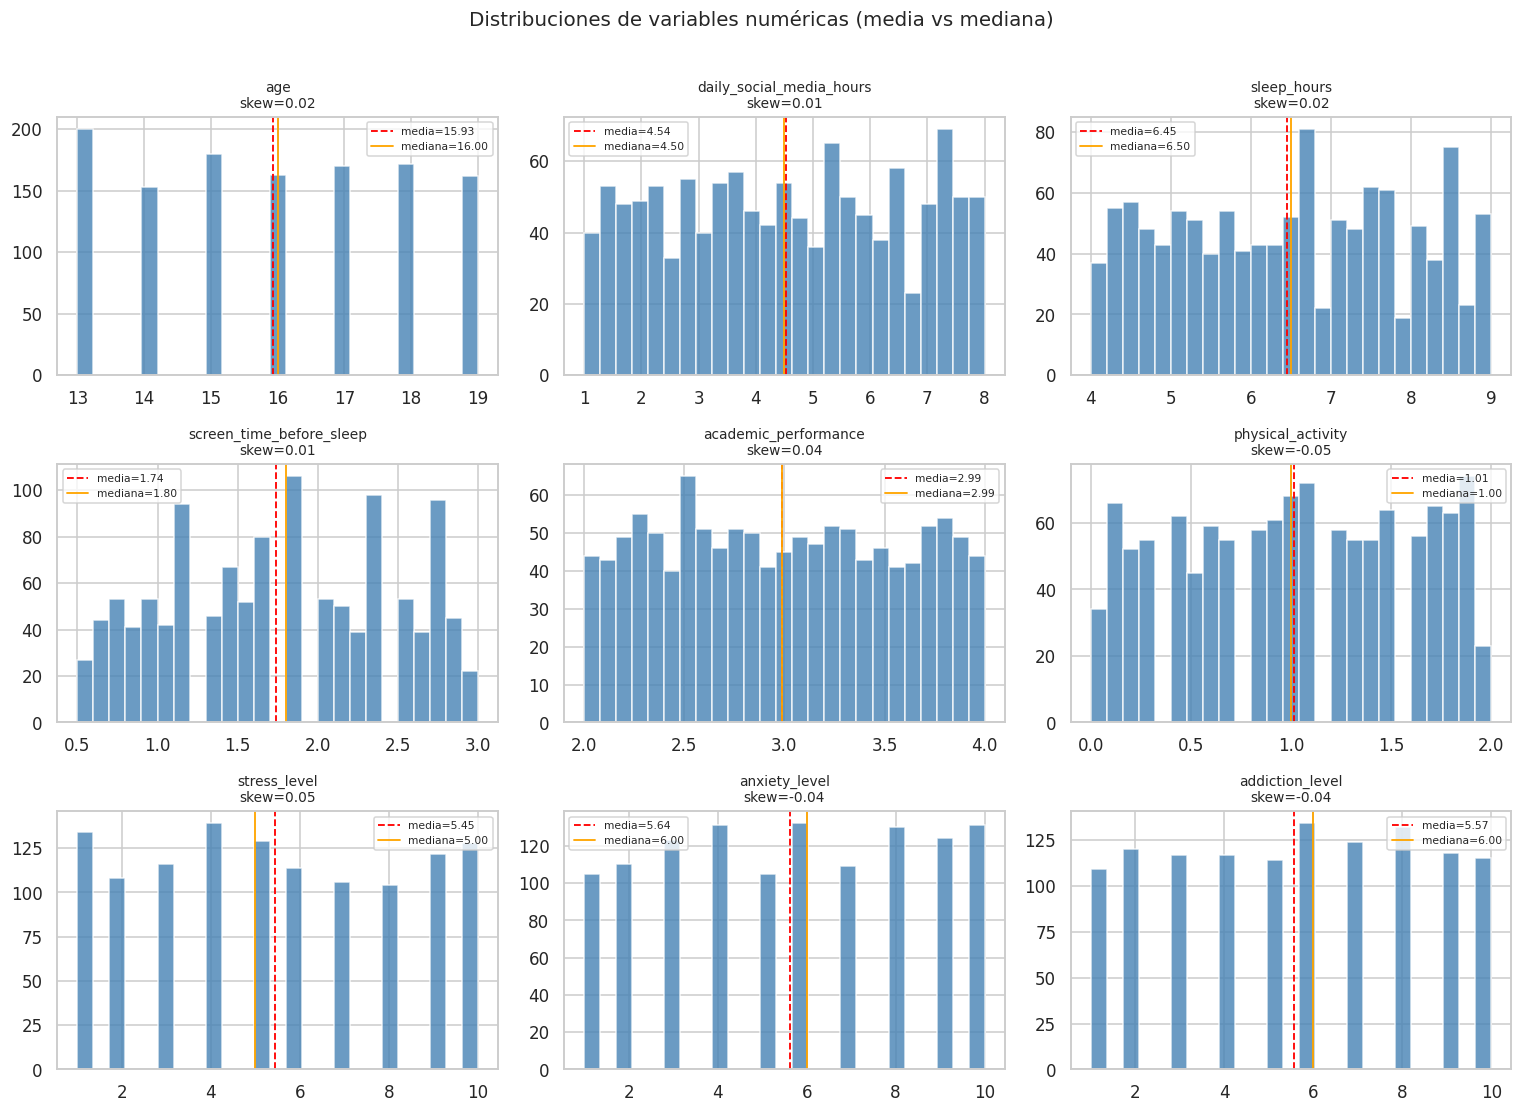

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    skew_val = df[col].skew()
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label=f'media={df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-', linewidth=1.2, label=f'mediana={df[col].median():.2f}')
    axes[i].set_title(f'{col}\nskew={skew_val:.2f}', fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Distribuciones de variables numéricas (media vs mediana)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Decisión: transformaciones por asimetría

Las variables de tipo escala Likert (`stress_level`, `anxiety_level`, `addiction_level`) son **discretas y acotadas entre 1 y 10**. Aunque presenten skewness leve, aplicar transformaciones logarítmicas sobre escalas ordinales acotadas distorsionaría el significado del espacio de valores sin beneficio garantizado.

**Criterio adoptado:** solo aplicar transformación logarítmica si `|skewness| > 1` **y** la variable es continua y no acotada artificialmente.  
Las variables con distribuciones aproximadamente simétricas y las escalas ordinales se dejarán sin transformar: el escalado posterior (StandardScaler) es suficiente para los modelos más comunes.

In [5]:
ordinal_scale_cols = {'stress_level', 'anxiety_level', 'addiction_level'}

cols_to_transform = [
    col for col in num_cols
    if abs(df[col].skew()) > 1 and col not in ordinal_scale_cols
]

if cols_to_transform:
    print('Columnas que recibirán transformación log1p:', cols_to_transform)
    for col in cols_to_transform:
        original_skew = df[col].skew()
        df[col] = np.log1p(df[col])
        new_skew = df[col].skew()
        print(f'  {col}: skew {original_skew:.3f} → {new_skew:.3f}')
else:
    print('Ninguna variable continua supera |skew| > 1. No se aplican transformaciones de forma.')

Ninguna variable continua supera |skew| > 1. No se aplican transformaciones de forma.


---
## 3. Detección y tratamiento de outliers

Usamos el criterio **IQR** (rango intercuartílico) para detectar outliers:

$$\text{límite inferior} = Q_1 - 1.5 \cdot IQR \quad;\quad \text{límite superior} = Q_3 + 1.5 \cdot IQR$$

Para las variables acotadas por diseño (Likert 1-10, horas de sueño 4-9, etc.), los extremos del rango son valores legítimos. Si el método IQR detecta outliers en estas variables, es señal de que la distribución tiene colas largas pero **no de valores erróneos**.

In [6]:
outlier_report = []

for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (df[col] < lo) | (df[col] > hi)
    n_out = mask.sum()
    pct = 100 * n_out / len(df)
    outlier_report.append({'feature': col, 'n_outliers': n_out, '%': round(pct, 2),
                           'lim_inf': round(lo, 3), 'lim_sup': round(hi, 3),
                           'min_real': df[col].min(), 'max_real': df[col].max()})

out_df = pd.DataFrame(outlier_report).set_index('feature')
print(out_df.to_string())

                          n_outliers    %  lim_inf  lim_sup  min_real  max_real
feature                                                                        
age                                0  0.0     8.00    24.00      13.0      19.0
daily_social_media_hours           0  0.0    -2.45    11.55       1.0       8.0
sleep_hours                        0  0.0     1.60    11.20       4.0       9.0
screen_time_before_sleep           0  0.0    -0.85     4.35       0.5       3.0
academic_performance               0  0.0     1.03     4.95       2.0       4.0
physical_activity                  0  0.0    -1.00     3.00       0.0       2.0
stress_level                       0  0.0    -4.50    15.50       1.0      10.0
anxiety_level                      0  0.0    -4.50    15.50       1.0      10.0
addiction_level                    0  0.0    -4.50    15.50       1.0      10.0


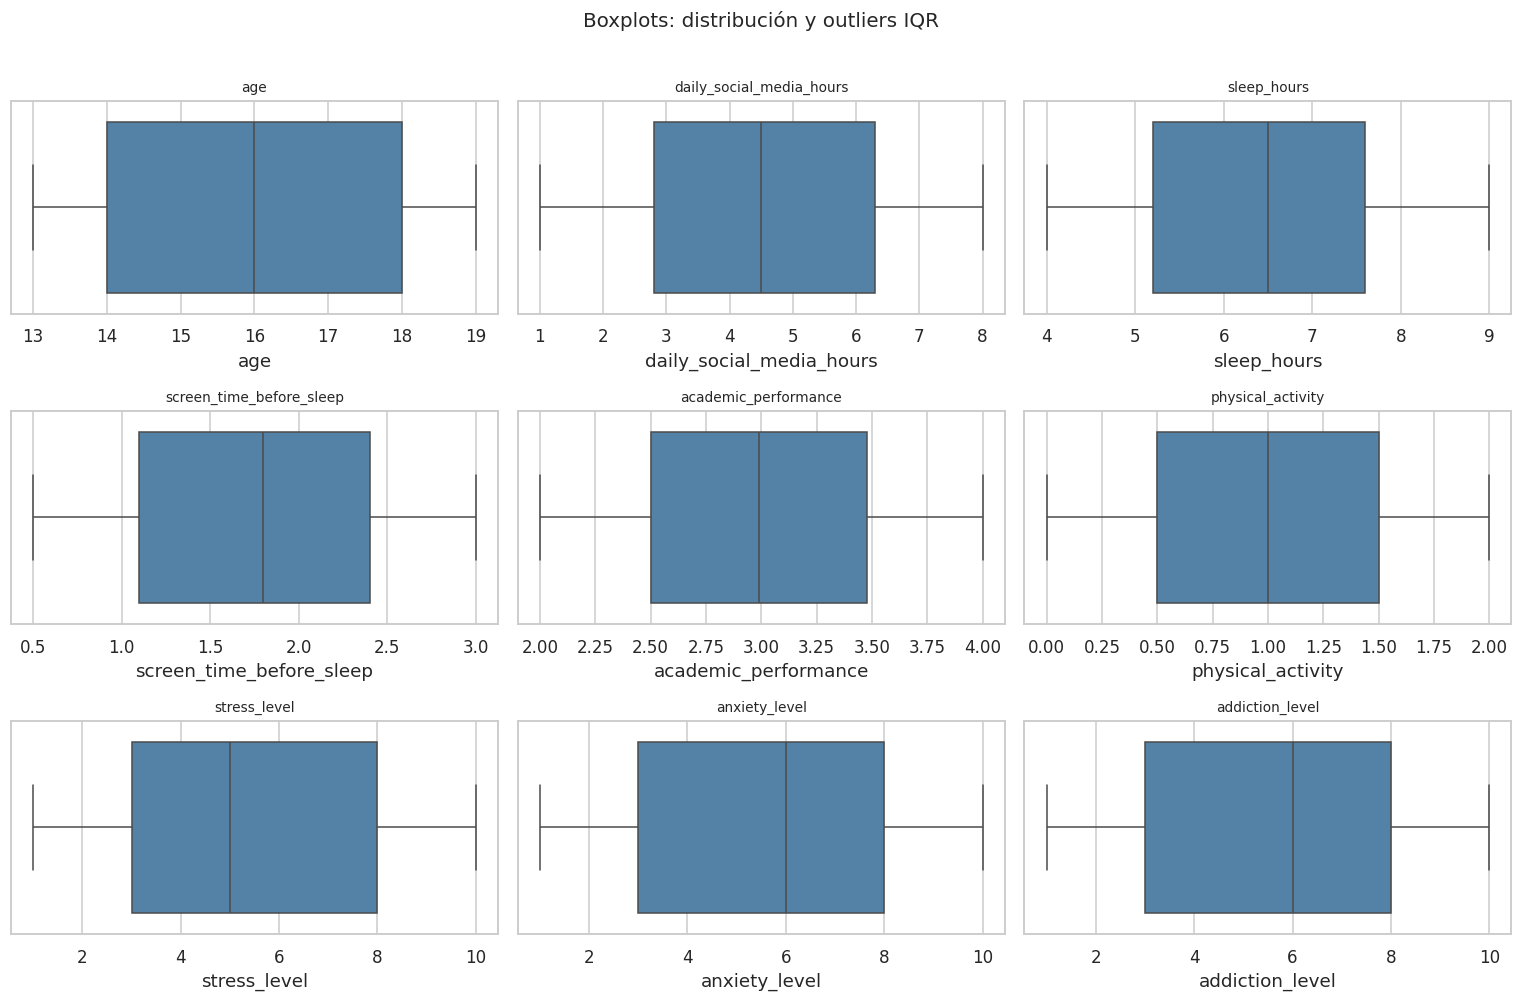

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='steelblue', flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Boxplots: distribución y outliers IQR', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Decisión: tratamiento de outliers

**No se eliminan ni se capturan (winsorizing) los outliers.** Razones:

1. **Valores legítimos en el dominio:** todas las variables tienen rangos acotados por el instrumento de recogida (escalas 1-10, edades 13-19, horas del día). Un adolescente con 10/10 en ansiedad es clínicamente posible y relevante para la tarea de clasificación.
2. **Porcentaje reducido:** si el % de outliers es bajo, eliminarlos tiene impacto mínimo en las distribuciones pero puede eliminar precisamente los casos positivos (clase 1), que son minoría.
3. **Robustez del escalado:** StandardScaler es sensible a outliers extremos, pero dado que los rangos están acotados, este efecto es limitado. Si se usaran modelos muy sensibles a outliers, se reconsideraría RobustScaler.

**Alternativa documentada para modelos sensibles:** Winsorizing al percentil 1-99 o RobustScaler en lugar de StandardScaler.

---
## 4. Desbalance de clases

El EDA reveló un desbalance severo: **97.4 % clase 0 / 2.6 % clase 1**.  
Un clasificador que prediga siempre 0 alcanza un 97.4 % de *accuracy* sin aprender nada útil.

Este notebook **documenta el problema y las estrategias disponibles** pero no aplica ninguna directamente porque la técnica óptima depende del algoritmo elegido en la fase de modelado.

In [8]:
counts = df['depression_label'].value_counts()
pcts   = df['depression_label'].value_counts(normalize=True) * 100

print('Distribución del target:')
summary = pd.DataFrame({'n': counts, '%': pcts.round(2)})
print(summary)

ratio = counts[0] / counts[1]
print(f'\nRatio de desbalance: {ratio:.1f}:1 (negativo:positivo)')

print('\nEstrategias disponibles para el modelado:')
estrategias = {
    'class_weight="balanced"': 'Ajustar pesos inversamente proporcionales a la frecuencia. Sin coste computacional adicional. Compatible con scikit-learn.',
    'SMOTE (oversampling)':     'Generar muestras sintéticas de la clase minoritaria interpolando entre vecinos. Reduce sesgo pero aumenta el dataset artificialmente.',
    'Undersampling aleatorio':  'Reducir la clase mayoritaria. Sencillo pero descarta información.',
    'Threshold tuning':         'Ajustar el umbral de decisión (default 0.5) para priorizar recall en clase 1 a costa de precision.',
    'Métricas robustas':        'Evaluar con F1-score, ROC-AUC, PR-AUC en lugar de accuracy.',
}
for k, v in estrategias.items():
    print(f'  • {k}: {v}')

Distribución del target:
                     n      %
depression_label             
0                 1169  97.42
1                   31   2.58

Ratio de desbalance: 37.7:1 (negativo:positivo)

Estrategias disponibles para el modelado:
  • class_weight="balanced": Ajustar pesos inversamente proporcionales a la frecuencia. Sin coste computacional adicional. Compatible con scikit-learn.
  • SMOTE (oversampling): Generar muestras sintéticas de la clase minoritaria interpolando entre vecinos. Reduce sesgo pero aumenta el dataset artificialmente.
  • Undersampling aleatorio: Reducir la clase mayoritaria. Sencillo pero descarta información.
  • Threshold tuning: Ajustar el umbral de decisión (default 0.5) para priorizar recall en clase 1 a costa de precision.
  • Métricas robustas: Evaluar con F1-score, ROC-AUC, PR-AUC en lugar de accuracy.


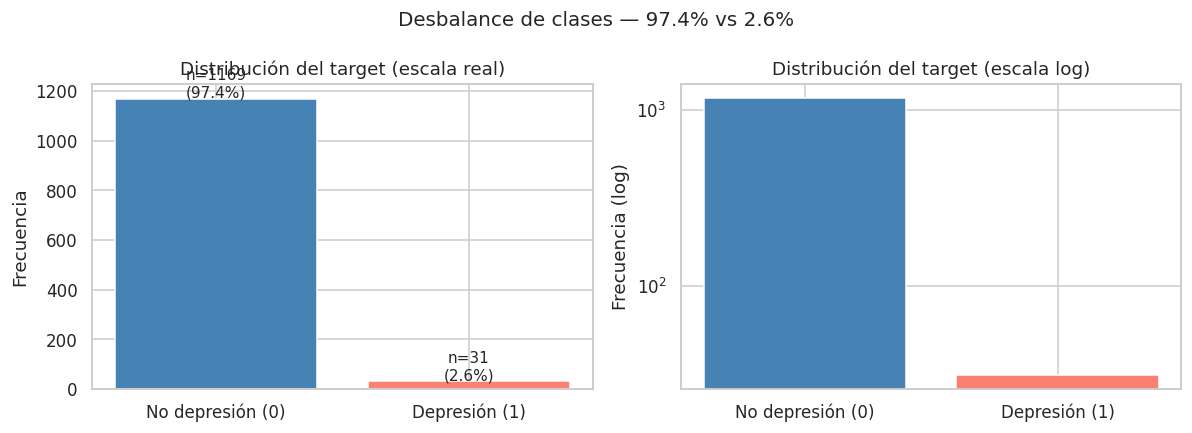

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts_vals = df['depression_label'].value_counts().sort_index()
bars = axes[0].bar(['No depresión (0)', 'Depresión (1)'], counts_vals.values,
                    color=['steelblue', 'salmon'], edgecolor='white')
for bar, n in zip(bars, counts_vals.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'n={n}\n({100*n/len(df):.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Distribución del target (escala real)')
axes[0].set_ylabel('Frecuencia')

axes[1].bar(['No depresión (0)', 'Depresión (1)'], counts_vals.values,
            color=['steelblue', 'salmon'], edgecolor='white', log=True)
axes[1].set_title('Distribución del target (escala log)')
axes[1].set_ylabel('Frecuencia (log)')

plt.suptitle('Desbalance de clases — 97.4% vs 2.6%', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Codificación de variables categóricas

Hay tres variables categóricas con naturalezas distintas que requieren estrategias de codificación diferentes:

| Variable | Tipo | Valores | Estrategia |
|---|---|---|---|
| `gender` | Binaria | male / female | Binaria directa (0/1) |
| `social_interaction_level` | Ordinal | low < medium < high | Ordinal encoding (0, 1, 2) |
| `platform_usage` | Nominal | Instagram / TikTok / Both | One-hot encoding |

### 5.1 `gender` — Codificación binaria

Con solo dos categorías, el one-hot encoding introduciría multicolinealidad perfecta (la columna eliminada es linealmente predecible desde la otra). La codificación binaria directa es suficiente.

In [10]:
print('Valores únicos de gender:', df['gender'].value_counts().to_dict())

df['gender'] = df['gender'].map({'male': 0, 'female': 1})

print('Tras codificación:')
print(df['gender'].value_counts())
print('Tipo:', df['gender'].dtype)

Valores únicos de gender: {'male': 615, 'female': 585}
Tras codificación:
gender
0    615
1    585
Name: count, dtype: int64
Tipo: int64


### 5.2 `social_interaction_level` — Codificación ordinal

Esta variable tiene un **orden natural claro**: `low < medium < high`.  
La codificación ordinal preserva este orden y permite que los modelos aprovechen la relación de magnitud.  
El one-hot encoding perdería esta información al tratar las categorías como independientes.

In [11]:
print('Distribución de social_interaction_level:')
print(df['social_interaction_level'].value_counts())

ordinal_map = {'low': 0, 'medium': 1, 'high': 2}
df['social_interaction_level'] = df['social_interaction_level'].map(ordinal_map)

print('\nTras codificación ordinal (low=0, medium=1, high=2):')
print(df['social_interaction_level'].value_counts().sort_index())

Distribución de social_interaction_level:
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

Tras codificación ordinal (low=0, medium=1, high=2):
social_interaction_level
0    415
1    416
2    369
Name: count, dtype: int64


### 5.3 `platform_usage` — One-hot encoding

Con tres categorías nominales (`Instagram`, `TikTok`, `Both`) **sin orden**, el one-hot encoding evita que el modelo asuma una relación de magnitud artificial entre plataformas.  
Se usa `drop_first=False` para conservar las tres dummies dado que no hay multicolinealidad perfecta a nivel del dataset completo. Si en el modelado se usa un algoritmo sensible a multicolinealidad (regresión logística, LDA), se eliminará una de las dummies.

In [12]:
print('Distribución de platform_usage:')
print(df['platform_usage'].value_counts())

platform_dummies = pd.get_dummies(df['platform_usage'], prefix='platform', dtype=int)
df = pd.concat([df.drop(columns='platform_usage'), platform_dummies], axis=1)

print('\nNuevas columnas:', list(platform_dummies.columns))
print('Shape tras one-hot:', df.shape)

Distribución de platform_usage:
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

Nuevas columnas: ['platform_Both', 'platform_Instagram', 'platform_TikTok']
Shape tras one-hot: (1200, 15)


---
## 6. Multicolinealidad entre variables numéricas

Antes de escalar, analizamos la **correlación entre features numéricas**. Una correlación alta entre predictores (multicolinealidad) puede:
- Inflar la varianza de los coeficientes en modelos lineales.
- Reducir la interpretabilidad.
- Dificultar la selección de features.

Umbral de alerta: **|r| > 0.70** (correlación fuerte).

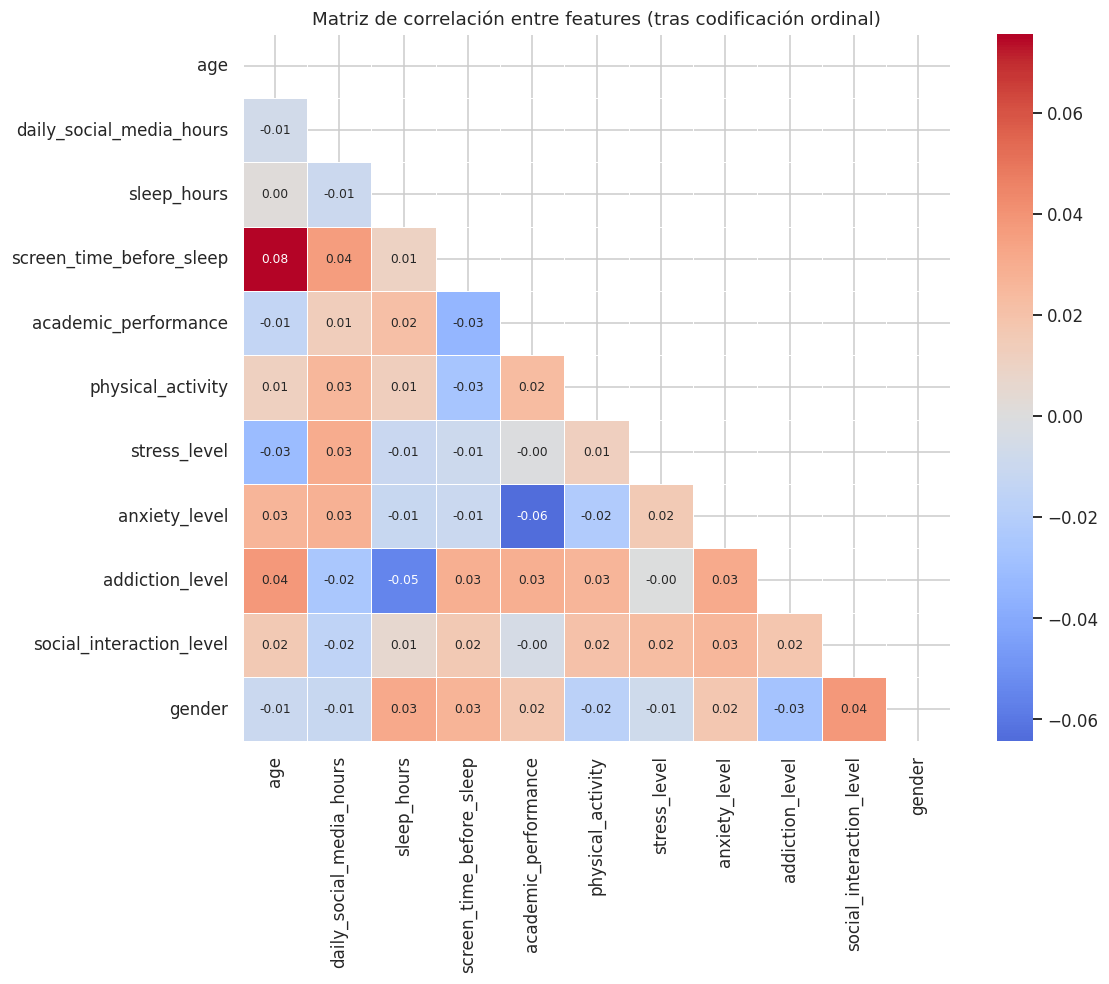

In [13]:
all_num = num_cols + ['social_interaction_level', 'gender']

corr_matrix = df[all_num].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de correlación entre features (tras codificación ordinal)', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
threshold = 0.70
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= threshold:
            high_corr_pairs.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlacion': round(val, 3)
            })

if high_corr_pairs:
    print(f'Pares con |r| >= {threshold}:')
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print(f'No hay pares de features con |r| >= {threshold}.')
    print('→ Sin multicolinealidad severa. Todas las variables pueden mantenerse.')

No hay pares de features con |r| >= 0.7.
→ Sin multicolinealidad severa. Todas las variables pueden mantenerse.


---
## 7. Relevancia de features respecto al target

Analizamos la correlación de Pearson de cada feature con `depression_label` y comparamos con la correlación punto-biserial (más apropiada cuando el target es binario).

**Criterio de exclusión conservador:** solo eliminar una feature si `|r| < 0.01` en ambas métricas **y** su eliminación no supone pérdida de información teórica. La correlación lineal débil no implica que la variable carezca de poder predictivo no lineal.

In [15]:
feature_cols = [c for c in df.columns if c != 'depression_label']

results = []
for col in feature_cols:
    pearson_r, pearson_p = stats.pearsonr(df[col], df['depression_label'])
    pb_r, pb_p = stats.pointbiserialr(df['depression_label'], df[col])
    results.append({
        'feature':    col,
        'pearson_r':  round(pearson_r, 4),
        'pearson_p':  round(pearson_p, 4),
        'pb_r':       round(pb_r, 4),
        'pb_p':       round(pb_p, 4),
    })

corr_target = pd.DataFrame(results).set_index('feature').sort_values('pearson_r')
print(corr_target.to_string())

                          pearson_r  pearson_p    pb_r    pb_p
feature                                                       
sleep_hours                 -0.1906     0.0000 -0.1906  0.0000
physical_activity           -0.0176     0.5425 -0.0176  0.5425
screen_time_before_sleep    -0.0165     0.5679 -0.0165  0.5679
addiction_level             -0.0140     0.6292 -0.0140  0.6292
platform_Both               -0.0123     0.6694 -0.0123  0.6694
platform_Instagram          -0.0068     0.8130 -0.0068  0.8130
academic_performance         0.0014     0.9602  0.0014  0.9602
age                          0.0110     0.7042  0.0110  0.7042
social_interaction_level     0.0142     0.6222  0.0142  0.6222
platform_TikTok              0.0192     0.5070  0.0192  0.5070
gender                       0.0198     0.4924  0.0198  0.4924
anxiety_level                0.1696     0.0000  0.1696  0.0000
stress_level                 0.1705     0.0000  0.1705  0.0000
daily_social_media_hours     0.1752     0.0000  0.1752 

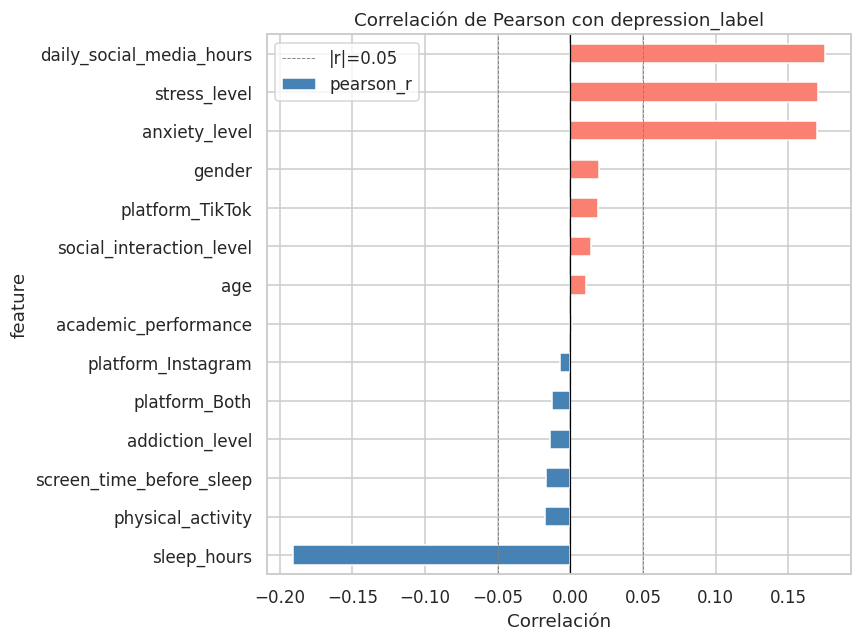

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['salmon' if v > 0 else 'steelblue' for v in corr_target['pearson_r']]
corr_target['pearson_r'].plot(kind='barh', color=colors, edgecolor='white', ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.05, color='gray', linewidth=0.6, linestyle='--', label='|r|=0.05')
ax.axvline(-0.05, color='gray', linewidth=0.6, linestyle='--')
ax.set_title('Correlación de Pearson con depression_label', fontsize=12)
ax.set_xlabel('Correlación')
ax.legend()
plt.tight_layout()
plt.show()

### Decisión: selección de features

**Se mantienen todas las variables** en el dataset de preprocesamiento por las siguientes razones:

- `sleep_hours` (r≈−0.19), `daily_social_media_hours` (r≈0.18), `stress_level` (r≈0.17), `anxiety_level` (r≈0.17) son los predictores más fuertes linealmente y con evidencia teórica clara.
- `age` (r≈0.01) y `academic_performance` (r≈0.00) muestran correlación lineal mínima, pero **la correlación de Pearson asume linealidad**. Algoritmos como árboles de decisión o redes neuronales pueden extraer relaciones no lineales de estas variables. Su eliminación prematura podría quitar información real.
- Las dummies de `platform_usage` también se mantienen por la misma razón.

**Si se desea reducir dimensionalidad** en fase de modelado, puede aplicarse: análisis de importancia de features (RandomForest), PCA, o eliminación recursiva de features (RFE).

---
## 8. Escalado de variables numéricas

Las variables numéricas tienen rangos distintos:

| Variable | Rango aproximado |
|---|---|
| `age` | 13 – 19 |
| `daily_social_media_hours` | 1 – 8 |
| `sleep_hours` | 4 – 9 |
| `screen_time_before_sleep` | 0.5 – 3 |
| `academic_performance` | 2 – 4 |
| `physical_activity` | 0 – 2 |
| `stress_level` | 1 – 10 |
| `anxiety_level` | 1 – 10 |
| `addiction_level` | 1 – 10 |

Sin escalado, algoritmos basados en distancia (KNN, SVM, regresión logística regularizada) o en gradiente descenderían más rápido por las variables de mayor escala, introduciendo un sesgo artificial.

**Elección: StandardScaler** (z-score: $z = \frac{x - \mu}{\sigma}$)

- Centra en 0 y escala por desviación estándar.
- Adecuado para distribuciones aproximadamente simétricas (confirmado en sección 2).
- Compatible con la mayoría de algoritmos de ML.
- **Alternativa documentada:** `MinMaxScaler` [0, 1] si se usan redes neuronales con activaciones sigmoides; `RobustScaler` si hubiera outliers relevantes.

In [17]:
cols_to_scale = num_cols + ['social_interaction_level']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print('Media y std tras StandardScaler (deben ser ≈0 y ≈1):')
check = pd.DataFrame({
    'mean_post': df_scaled[cols_to_scale].mean().round(6),
    'std_post':  df_scaled[cols_to_scale].std().round(6)
})
print(check.to_string())

Media y std tras StandardScaler (deben ser ≈0 y ≈1):
                          mean_post  std_post
age                             0.0  1.000417
daily_social_media_hours       -0.0  1.000417
sleep_hours                    -0.0  1.000417
screen_time_before_sleep        0.0  1.000417
academic_performance           -0.0  1.000417
physical_activity              -0.0  1.000417
stress_level                   -0.0  1.000417
anxiety_level                  -0.0  1.000417
addiction_level                -0.0  1.000417
social_interaction_level        0.0  1.000417


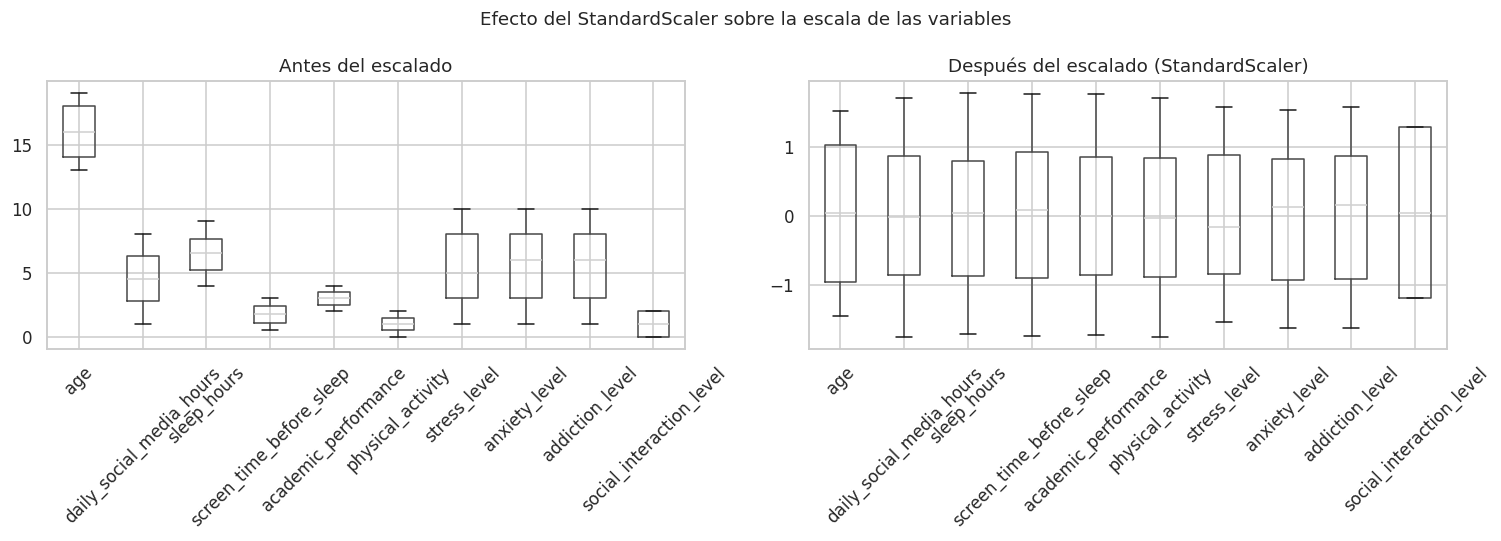

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[cols_to_scale].boxplot(ax=axes[0])
axes[0].set_title('Antes del escalado')
axes[0].tick_params(axis='x', rotation=45)

df_scaled[cols_to_scale].boxplot(ax=axes[1])
axes[1].set_title('Después del escalado (StandardScaler)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Efecto del StandardScaler sobre la escala de las variables', fontsize=12)
plt.tight_layout()
plt.show()

---
## 9. Dataset final y guardado

Compilamos el dataset preprocesado con todas las transformaciones aplicadas.

In [19]:
df_final = df_scaled.copy()

print('=== Dataset preprocesado ===')
print(f'Shape: {df_final.shape}')
print(f'Columnas: {list(df_final.columns)}')
print(f'\nNulos: {df_final.isnull().sum().sum()}')
print(f'Tipos de datos:')
print(df_final.dtypes)

df_final.head()

=== Dataset preprocesado ===
Shape: (1200, 15)
Columnas: ['age', 'gender', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label', 'platform_Both', 'platform_Instagram', 'platform_TikTok']

Nulos: 0
Tipos de datos:
age                         float64
gender                        int64
daily_social_media_hours    float64
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level    float64
stress_level                float64
anxiety_level               float64
addiction_level             float64
depression_label              int64
platform_Both                 int64
platform_Instagram            int64
platform_TikTok               int64
dtype: object


,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_Both,platform_Instagram,platform_TikTok
0,-0.954099,0,1.657833,0.659177,1.618830,0.034026,0.834276,-1.191094,-1.187367,-1.272335,-1.613389,0,0,1,0
1,1.519796,1,-1.299649,1.075244,1.618830,0.398282,-0.368593,1.286051,0.880116,-1.622199,1.567444,0,0,0,1
2,0.530238,1,-1.595397,0.797866,-1.731436,1.612470,-1.743301,1.286051,-1.187367,-0.572609,-1.259963,0,0,1,0
3,-0.459320,0,1.411376,0.312455,-0.195897,0.849266,-0.368593,0.047479,-1.531947,0.476980,1.214018,0,0,0,1
4,-0.459320,1,0.080509,-1.074435,1.758424,-1.076088,0.662437,0.047479,-0.842786,-0.222746,-1.259963,0,1,0,0


In [20]:
import os
os.makedirs('../data/processed', exist_ok=True)

df_final.to_csv('../data/processed/teen_mental_health_preprocessed.csv', index=False)
print('Dataset guardado en: data/processed/teen_mental_health_preprocessed.csv')
print(f'Shape final: {df_final.shape}')

Dataset guardado en: data/processed/teen_mental_health_preprocessed.csv
Shape final: (1200, 15)


---
## 10. Resumen de decisiones de preprocesamiento

| Paso | Decisión | Justificación estadística |
|---|---|---|
| **Nulos / duplicados** | Sin acción | 0 nulos, 0 duplicados (confirmado) |
| **Transformación de forma** | Solo si \|skew\| > 1 en variables continuas no acotadas | Evita distorsionar escalas Likert; distribuciones próximas a la simetría no se benefician del log |
| **Outliers** | Sin eliminación ni capping | Valores extremos son legítimos (escalas acotadas); porcentaje reducido |
| **Desbalance de clases** | Documentado, tratamiento diferido al modelado | La técnica óptima depende del algoritmo (class_weight vs SMOTE vs umbral) |
| **`gender`** | Binaria (male=0, female=1) | Solo 2 categorías; one-hot introduciría colinealidad perfecta |
| **`social_interaction_level`** | Ordinal (low=0, medium=1, high=2) | Orden natural claro; ordinal preserva la relación de magnitud |
| **`platform_usage`** | One-hot (3 dummies) | Sin orden entre plataformas; one-hot evita relación numérica artificial |
| **Selección de features** | Todas conservadas | Correlación lineal débil ≠ ausencia de poder predictivo no lineal |
| **Escalado** | StandardScaler (z-score) | Variables en escalas dispares; distribuciones simétricas; compatibilidad amplia |

**Próximo paso:** `03_modeling.ipynb` — entrenamiento de clasificadores con evaluación sobre métricas robustas al desbalance (F1, ROC-AUC, PR-AUC).